In [ ]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


In [ ]:
from google.colab import files
uploaded = files.upload()
DATA_PATH = list(uploaded.keys())[0]
print("Using:", DATA_PATH)

Saving clean_aqi.csv to clean_aqi.csv
Using: clean_aqi.csv


In [ ]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TARGET_COL     = "european_aqi"
SEQUENCE_LEN   = 24
FORECAST_STEPS = 1

FEATURE_COLS = [
    "european_aqi", "pm10", "pm2_5",
    "temperature_2m", "relative_humidity_2m",
    "precipitation", "snowfall", "cloud_cover",
    "wind_speed_10m", "wind_gusts_10m",
    "weather_code", "hour", "day_of_week", "month",
]

HIDDEN_SIZE    = 128
NUM_LAYERS     = 2
DROPOUT        = 0.2
BATCH_SIZE     = 64
EPOCHS         = 50
LEARNING_RATE  = 1e-3
WEIGHT_DECAY   = 1e-5
PATIENCE       = 10
TRAIN_RATIO    = 0.70
VAL_RATIO      = 0.15
OUTPUT_DIR     = "lstm_outputs"
SEED           = 42

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
os.makedirs(OUTPUT_DIR, exist_ok=True)

Device: cuda


In [ ]:
df = pd.read_csv(DATA_PATH, parse_dates=["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)
df = df[["datetime"] + FEATURE_COLS].dropna()

print(f"Rows: {len(df):,}")
print(f"Range: {df['datetime'].min()} → {df['datetime'].max()}")
print(f"Nulls: {df.isnull().sum().sum()}")
df.describe()

Rows: 35,064
Range: 2022-03-30 00:00:00 → 2026-03-29 23:00:00
Nulls: 0


,datetime,european_aqi,pm10,pm2_5,temperature_2m,relative_humidity_2m,precipitation,snowfall,cloud_cover,wind_speed_10m,wind_gusts_10m,weather_code,hour,day_of_week,month
count,35064,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000
mean,2024-03-29 11:30:00,40.498488,22.280963,18.401283,12.267077,74.969770,0.120254,0.014276,56.732204,5.461111,18.664511,11.847878,11.500000,3.003422,6.522930
min,2022-03-30 00:00:00,13.000000,1.900000,1.300000,-14.100000,11.000000,0.000000,0.000000,0.000000,0.000000,2.200000,0.000000,0.000000,0.000000,1.000000
25%,2023-03-30 05:45:00,27.000000,11.400000,8.900000,5.600000,63.000000,0.000000,0.000000,8.000000,3.300000,12.200000,0.000000,5.750000,1.000000,4.000000
50%,2024-03-29 11:30:00,34.000000,17.300000,13.300000,12.000000,80.000000,0.000000,0.000000,68.000000,5.000000,16.600000,2.000000,11.500000,3.000000,7.000000
75%,2025-03-29 17:15:00,54.000000,26.500000,21.000000,18.400000,89.000000,0.000000,0.000000,100.000000,7.100000,22.700000,3.000000,17.250000,5.000000,10.000000
max,2026-03-29 23:00:00,117.000000,235.100000,227.600000,37.300000,100.000000,22.500000,4.690000,100.000000,33.600000,94.700000,75.000000,23.000000,6.000000,12.000000
std,NaN,17.853278,17.859747,16.686919,8.562893,17.738089,0.534914,0.123247,42.250326,3.119055,9.218308,21.865846,6.922285,1.999170,3.448752


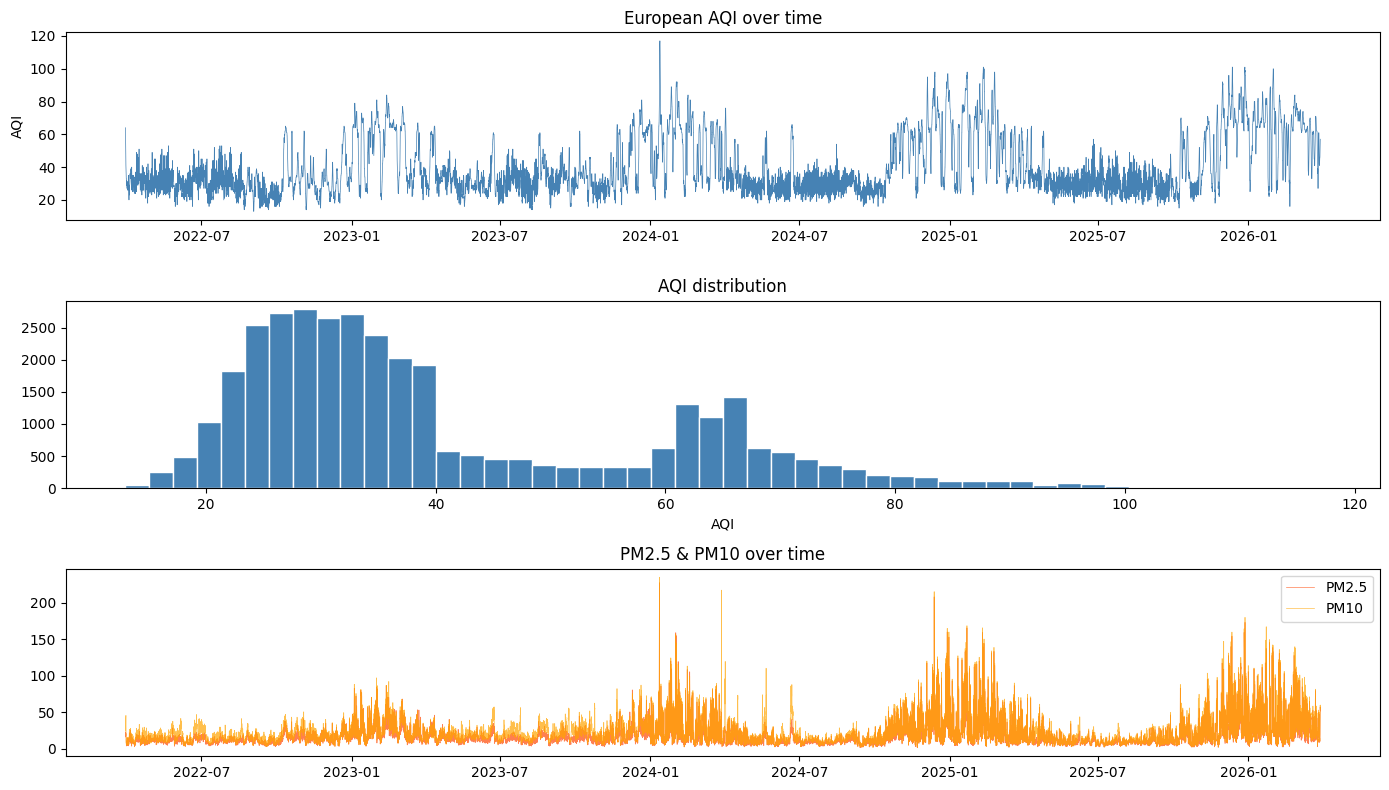

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

axes[0].plot(df["datetime"], df["european_aqi"], linewidth=0.5, color="steelblue")
axes[0].set_title("European AQI over time"); axes[0].set_ylabel("AQI")

axes[1].hist(df["european_aqi"], bins=50, color="steelblue", edgecolor="white")
axes[1].set_title("AQI distribution"); axes[1].set_xlabel("AQI")

axes[2].plot(df["datetime"], df["pm2_5"], linewidth=0.5, color="coral", label="PM2.5")
axes[2].plot(df["datetime"], df["pm10"],  linewidth=0.5, color="orange", label="PM10", alpha=0.7)
axes[2].set_title("PM2.5 & PM10 over time"); axes[2].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda.png", dpi=150)
plt.show()

In [ ]:
data = df[FEATURE_COLS].values
n    = len(data)

train_end = int(n * TRAIN_RATIO)
val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))

train_raw, val_raw, test_raw = data[:train_end], data[train_end:val_end], data[val_end:]

scaler   = MinMaxScaler()
train_sc = scaler.fit_transform(train_raw)
val_sc   = scaler.transform(val_raw)
test_sc  = scaler.transform(test_raw)

print(f"Train: {len(train_sc):,}  Val: {len(val_sc):,}  Test: {len(test_sc):,}")

Train: 24,544  Val: 5,260  Test: 5,260


In [ ]:
TARGET_IDX = FEATURE_COLS.index(TARGET_COL)

class AQIDataset(Dataset):
    def __init__(self, data, seq_len, forecast_steps, target_idx):
        self.data, self.seq_len = data, seq_len
        self.forecast_steps, self.target_idx = forecast_steps, target_idx

    def __len__(self):
        return len(self.data) - self.seq_len - self.forecast_steps + 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + self.seq_len : idx + self.seq_len + self.forecast_steps, self.target_idx]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

train_loader = DataLoader(AQIDataset(train_sc, SEQUENCE_LEN, FORECAST_STEPS, TARGET_IDX), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(AQIDataset(val_sc,   SEQUENCE_LEN, FORECAST_STEPS, TARGET_IDX), batch_size=BATCH_SIZE)
test_loader  = DataLoader(AQIDataset(test_sc,  SEQUENCE_LEN, FORECAST_STEPS, TARGET_IDX), batch_size=BATCH_SIZE)

print(f"Batches — train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}")

Batches — train: 384  val: 82  test: 82


In [ ]:
class LSTMPredictor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout, forecast_steps):
        super().__init__()
        self.lstm    = nn.LSTM(input_size, hidden_size, num_layers,
                               dropout=dropout if num_layers > 1 else 0.0,
                               batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, forecast_steps)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1, :]))

model = LSTMPredictor(len(FEATURE_COLS), HIDDEN_SIZE, NUM_LAYERS, DROPOUT, FORECAST_STEPS).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(model)

Parameters: 205,953
LSTMPredictor(
  (lstm): LSTM(14, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [ ]:
criterion  = nn.MSELoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=PATIENCE//2, factor=0.5)

history    = {"train": [], "val": []}
best_val, no_improve, best_state = float("inf"), 0, None

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item() * len(xb)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            val_loss += criterion(model(xb.to(device)), yb.to(device)).item() * len(xb)
    val_loss /= len(val_loader.dataset)

    scheduler.step(val_loss)
    history["train"].append(train_loss)
    history["val"].append(val_loss)
    print(f"Epoch {epoch:03d}/{EPOCHS}  train={train_loss:.5f}  val={val_loss:.5f}")

    if val_loss < best_val:
        best_val, no_improve = val_loss, 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
print(f"\nBest val loss: {best_val:.5f}")

Epoch 001/50  train=0.00329  val=0.00133
Epoch 002/50  train=0.00084  val=0.00058
Epoch 003/50  train=0.00061  val=0.00047
Epoch 004/50  train=0.00052  val=0.00045
Epoch 005/50  train=0.00044  val=0.00038
Epoch 006/50  train=0.00042  val=0.00036
Epoch 007/50  train=0.00038  val=0.00030
Epoch 008/50  train=0.00036  val=0.00025
Epoch 009/50  train=0.00035  val=0.00032
Epoch 010/50  train=0.00034  val=0.00026
Epoch 011/50  train=0.00033  val=0.00026
Epoch 012/50  train=0.00032  val=0.00025
Epoch 013/50  train=0.00032  val=0.00027
Epoch 014/50  train=0.00030  val=0.00025
Epoch 015/50  train=0.00031  val=0.00025
Epoch 016/50  train=0.00032  val=0.00024
Epoch 017/50  train=0.00031  val=0.00043
Epoch 018/50  train=0.00030  val=0.00024
Epoch 019/50  train=0.00031  val=0.00033
Epoch 020/50  train=0.00030  val=0.00022
Epoch 021/50  train=0.00030  val=0.00023
Epoch 022/50  train=0.00030  val=0.00028
Epoch 023/50  train=0.00030  val=0.00025
Epoch 024/50  train=0.00030  val=0.00030
Epoch 025/50  tr

In [ ]:
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        all_preds.append(model(xb.to(device)).cpu().numpy())
        all_true.append(yb.numpy())

preds_sc = np.concatenate(all_preds)
true_sc  = np.concatenate(all_true)

def inv_scale(arr):
    dummy = np.zeros((len(arr), scaler.scale_.shape[0]))
    dummy[:, TARGET_IDX] = arr
    return scaler.inverse_transform(dummy)[:, TARGET_IDX]

preds_inv = inv_scale(preds_sc[:, 0])
true_inv  = inv_scale(true_sc[:, 0])

print(f"MAE  = {mean_absolute_error(true_inv, preds_inv):.3f}")
print(f"RMSE = {mean_squared_error(true_inv, preds_inv)**0.5:.3f}")
print(f"R²   = {r2_score(true_inv, preds_inv):.4f}")

MAE  = 0.957
RMSE = 1.270
R²   = 0.9964


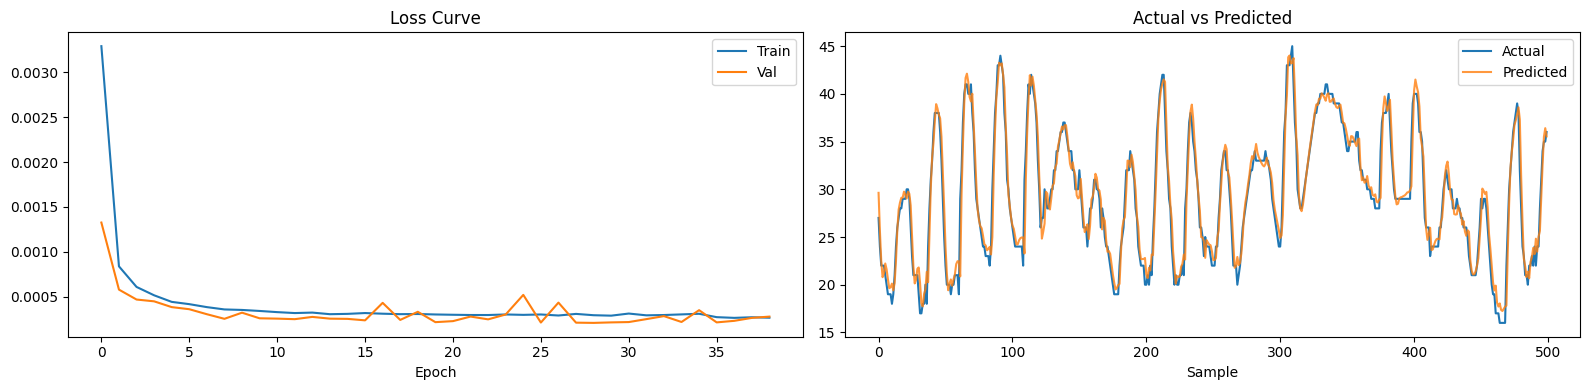

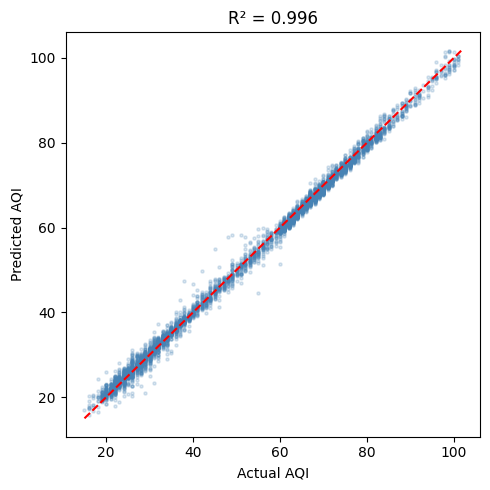

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(history["train"], label="Train")
axes[0].plot(history["val"],   label="Val")
axes[0].set_title("Loss Curve"); axes[0].set_xlabel("Epoch"); axes[0].legend()

n_show = min(500, len(true_inv))
axes[1].plot(true_inv[:n_show],  label="Actual",    linewidth=1.5)
axes[1].plot(preds_inv[:n_show], label="Predicted", linewidth=1.5, alpha=0.8)
axes[1].set_title("Actual vs Predicted"); axes[1].set_xlabel("Sample"); axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/results.png", dpi=150)
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(true_inv, preds_inv, alpha=0.2, s=5, color="steelblue")
lims = [min(true_inv.min(), preds_inv.min()), max(true_inv.max(), preds_inv.max())]
plt.plot(lims, lims, "r--", linewidth=1.5)
plt.xlabel("Actual AQI"); plt.ylabel("Predicted AQI")
plt.title(f"R² = {r2_score(true_inv, preds_inv):.3f}")
plt.tight_layout(); plt.show()

In [ ]:
ckpt = "lstm_outputs/lstm_aqi_best.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "feature_cols": FEATURE_COLS,
    "target_col": TARGET_COL,
    "sequence_len": SEQUENCE_LEN,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
}, ckpt)
print("Saved:", ckpt)

from google.colab import files
files.download(ckpt)

Saved: lstm_outputs/lstm_aqi_best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>